In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from pyvis.network import Network

In [2]:
def is_all_zero(byte_string):
    # Check if all bytes are zero
    return  byte_string == b'\x00' * len(byte_string)

class GraphState:
    def __init__(self, z_state, x_state):
        # z_state and x_state should be numpy arrays
        self.z_state = z_state
        self.x_state = x_state
        self.parents = []
        self.children = []

    def add_child(self, child_state):
        self.children.append(child_state)
        child_state.parents.append(self)

    def apply_mixer(self, beta):
        new_states = []
        z_indices = [i for i, z in enumerate(self.z_state) if z == 1]  # Find qubits with Z

        # Generate all combinations of applying X (apply or not apply) on qubits with Z
        for combination in itertools.product([0, 1], repeat=len(z_indices)):
            new_x_state = np.copy(self.x_state)

            for idx, apply_x in zip(z_indices, combination):
                if apply_x:  # If we apply X on this qubit
                    new_x_state[idx] = 1 - new_x_state[idx]  # Flip X state


            new_state = GraphState(np.copy(self.z_state), new_x_state)
            new_states.append(new_state)

        return new_states

    def apply_hamiltonian(self, gamma, adjacency_matrix):
        new_states = []

        num_qubits = len(self.z_state)

        # Generate all pairs of adjacent qubits based on the adjacency matrix
        adjacent_pairs = [(i, j) for i in range(num_qubits) for j in range(i + 1, num_qubits) if adjacency_matrix[i][j] == 1]


        # Generate all combinations of applying ZZ interaction on adjacent pairs
        for combination in itertools.product([0, 1], repeat=len(adjacent_pairs)):
                new_z_state = np.copy(self.z_state)

                # Apply ZZ interactions for each pair in the combination
                for (apply_zz, (i, j)) in zip(combination, adjacent_pairs):
                    if apply_zz and (self.x_state[i] == 1 or self.x_state[j] == 1) and not (self.x_state[i] == self.x_state[j]):
                        # Apply ZZ interaction (flip Z states at i and j)
                        new_z_state[i] = 1 - new_z_state[i]
                        new_z_state[j] = 1 - new_z_state[j]
                        
                # Generate the new state after applying the combination of ZZ interactions
                new_state = GraphState(new_z_state, np.copy(self.x_state))
                new_states.append(new_state)

        return new_states




    def __str__(self):
        return f"Z: {self.z_state}, X: {self.x_state}"

    def string_repr(self):
        return (self.z_state.tobytes(), self.x_state.tobytes())  # Unique representation for hashing


class MetaGraph:
    def __init__(self, initial_state, adjacency_matrix, angles):
        self.nodes = [initial_state]  # List of graph states (starting from the initial state)
        self.processed_states = {}  # Store processed states as keys (z, x) -> GraphState object
        self.states = set()  # To track visited states using string representations
        self.angles = angles  # List of (beta, gamma) pairs for each QAOA layer
        self.adjacency_matrix = adjacency_matrix
        self.init_state = initial_state

        # Add initial state
        self.states.add(initial_state.string_repr())

    def evolve_step(self, meta_nodes, angle, by_layer=True):
        beta, gamma = angle
        inter_states = []
        final_states = []

        # First apply mixer (beta)
        for state in meta_nodes:
            if state.string_repr() not in self.processed_states:
                mixer_states = state.apply_mixer(beta)
                for new_state in mixer_states:
                    state.add_child(new_state)
                    inter_states.append(new_state)

                self.processed_states[state.string_repr()] = None  # Mark as processed

        # Then apply problem Hamiltonian (gamma)
        for state in inter_states:
            hamiltonian_states = state.apply_hamiltonian(gamma, self.adjacency_matrix)
            for new_state in hamiltonian_states:
                state.add_child(new_state)
                if new_state.string_repr() not in self.states:
                    final_states.append(new_state)
                    self.states.add(new_state.string_repr())

        
        if by_layer:
            return inter_states + final_states
        return final_states

    def evolve(self, by_layer=True):
        new_arr = self.nodes
        for angle in self.angles:
            new_arr = self.evolve_step(new_arr, angle,by_layer)
            self.nodes += new_arr  # Add new states to the list of nodes
        self.last_nodes = {s.string_repr() for s in new_arr}
        
    def display_graph_txt(self):
        for state in self.nodes:
            print(state)

    def display_graph_nx(self):
        G = nx.DiGraph()
        node_labels = {}
        node_colors = []

        # Add all nodes and edges to the graph
        for state in self.nodes:
            state_id = state.string_repr()
            G.add_node(state_id)
            node_labels[state_id] = f"Z: {state.z_state}, X: {state.x_state}"
            for child in state.children:
                child_id = child.string_repr()
                G.add_edge(state_id, child_id)

        for node in G.nodes:
            if node == self.init_state.string_repr():
                node_colors.append("green")  # Initial state is green
            elif node in self.last_nodes:
                # print(node[0], is_all_zero(node[0]))
                if is_all_zero(node[0]):
                    node_colors.append("red")  # Last evolved nodes are red
                else:
                    node_colors.append("purple")
            else:
                node_colors.append("lightblue")  # Intermediate nodes are blue

        # Draw the graph using spring layout
        pos = nx.spring_layout(G)  # Spring layout for a balanced display
        plt.figure(figsize=(10, 10))
        nx.draw(G, pos, with_labels=True, labels=node_labels, node_size=2000, 
                node_color=node_colors, 
                font_size=8, font_family="sans-serif", edge_color="gray")

        plt.show()

    def display_graph_pyvis(self, output_file="graph.html"):
        G = nx.DiGraph()
        node_labels = {}

        # Create the pyvis network
        net = Network(notebook=True, height="750px", width="100%", directed=True)
        
        # Add all nodes and edges to the graph
        for state in self.nodes:
            state_id = state.string_repr()
            G.add_node(state_id)
            node_labels[state_id] = f"Z: {state.z_state}, X: {state.x_state}"
            for child in state.children:
                child_id = child.string_repr()
                G.add_edge(state_id, child_id)
        
        nodes_dict = {}
        # Add nodes and edges to pyvis network with color coding
        for i,node in enumerate(G.nodes()):
            nodes_dict[node] = i
            label = node_labels[node]
            if node == self.init_state.string_repr():
                color = "green"  # Initial node
            elif node in self.last_nodes:

                if is_all_zero(node[0]):
                    color = "red"  # Last evolved nodes are red
                else:
                    color = "purple"

            else:
                color = "lightblue"  # Intermediate nodes
            net.add_node(i, label=label, color=color)

        # # Add edges
        for edge in G.edges():
            net.add_edge(nodes_dict[edge[0]], nodes_dict[edge[1]])

        # Customize physics for better layout visualization
        net.show_buttons(filter_=['physics'])
        
        # Save and display graph
        net.show(output_file)
        print(f"Graph saved to {output_file}")


In [9]:
n = 6
edges = [[i, i+1] for i in range(n-1)] + [[n-1,0]]

G = nx.from_edgelist(edges)

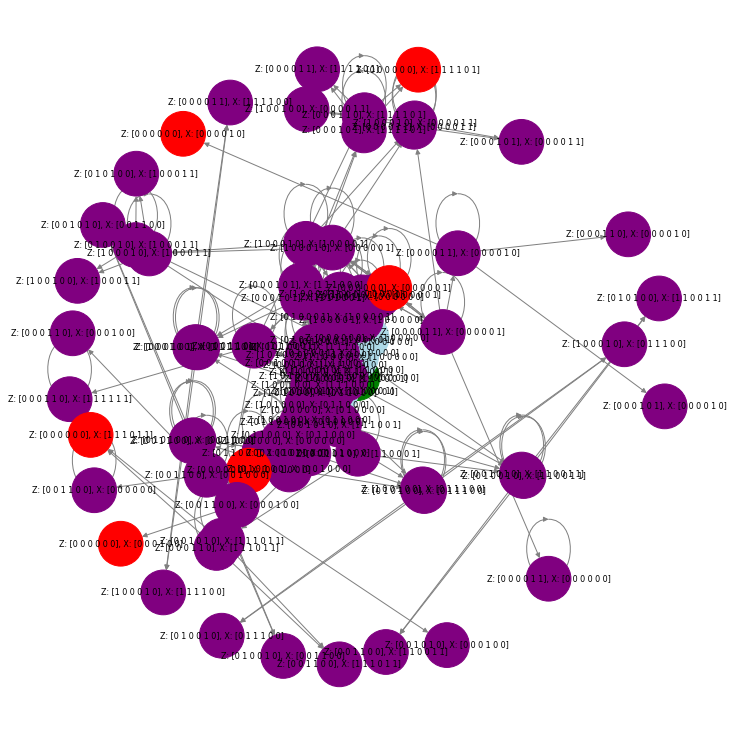

In [10]:
# Define adjacency matrix for a ring of 5 nodes
adjacency_matrix = nx.adjacency_matrix(G).todense().tolist()


# Initialize QAOA layers with specific beta and gamma angles
number_of_layers = 3
qaoa_layers = [(0.3, 0.5)] * number_of_layers

# Create the initial graph state (starting with Z on two adjacent qubits)
initial_state = GraphState(z_state=np.array([1, 1] + [0]*(n-2)), x_state=np.array([0]*n))

# Create MetaGraph and run evolution
meta_graph = MetaGraph(initial_state, adjacency_matrix, qaoa_layers)
meta_graph.evolve()


# Display the evolved graph states
# meta_graph.display_graph_txt()

# Display graph using networkx
meta_graph.display_graph_nx()


In [5]:
meta_graph.display_graph_pyvis()

graph.html
Graph saved to graph.html
